### ***First, let's make sure the necessary libraries are imported and Google Drive is mounted for starting your Explorative Data Analysis (EDA)***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **#1. Load your dataset and check its contents. This is the first step of your EDA process**

In [2]:
csv_file_path = "/content/drive/MyDrive/cleaned_fitness_watches.csv"  # Update path if needed

na_values = ["None", "none", "NA", "N/A", "n/a", "null", "NULL", "-", ""]

df = pd.read_csv(csv_file_path, na_values=na_values, encoding='utf-8-sig')

df.info()

display(df.shape)

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Name                         159 non-null    object 
 1   Brand                        159 non-null    object 
 2   Current Price                159 non-null    float64
 3   Original Price               159 non-null    float64
 4   Discount %                   159 non-null    float64
 5   Strap Colour                 159 non-null    object 
 6   Strap Type                   159 non-null    object 
 7   Watch Shape                  159 non-null    object 
 8   Display Size                 159 non-null    object 
 9   Display Type                 159 non-null    object 
 10  Calorie Count                159 non-null    bool   
 11  Step Count                   159 non-null    bool   
 12  Heart Rate Monitor           159 non-null    bool   
 13  Health Features     

(159, 24)

,Name,Brand,Current Price,Original Price,Discount %,Strap Colour,Strap Type,Watch Shape,Display Size,Display Type,...,Smart Functions,brand,parent_company,number_of_associated_brands,Calculated Discount %,Discount Suspicious,Display Size (inches),Health Feature Count,Smart Feature Count,Price Anomaly
0,ULTRON Model Fitness Health Music Smartwatch: ...,ULTRON,905.0,859.0,84.0,Black,Metal,Round,"8""",AMOLED,...,BT Calling,ULTRON,ULTRON,0,-5.4,True,8.0,4,1,True
1,Ezerio Gen 9 Smart Watch for Women with Sleek ...,Ezerio,2416.0,1357.0,84.0,Black,Metal,Round,"8""",AMOLED,...,"BT Calling, Voice Assistant",Ezerio,Ezerio,0,-78.0,True,8.0,5,2,True
2,"RGV H9 BT Calling, Fitness tracking Multiple W...",RGV,682.0,691.0,85.0,Black,Metal,Round,"8""",AMOLED,...,BT Calling,RGV,RGV,0,1.3,True,8.0,5,1,False
3,Nikki Trades Gen 9 Model Fitness Health Music ...,Nikki,1470.0,4999.0,84.0,Black,Metal,Round,"8""",AMOLED,...,BT Calling,Nikki,Nikki,0,70.6,False,8.0,4,1,False
4,OXILAG 5G Gen9 Smart watch With calling Notifi...,OXILAG,959.0,911.0,70.0,Black,Metal,Round,"8""",AMOLED,...,BT Calling,OXILAG,OXILAG,0,-5.3,True,8.0,5,1,True


# **#2. Check for missing values — understand which columns have gaps**

In [3]:
print("\n🔹 Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("✅ No missing values found!")
else:
    display(missing_df)

    # Visualize missing values
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_df.index, y=missing_df['Missing %'], palette='Reds_r')
    plt.title('Missing Values by Column (%)')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Missing %')
    plt.tight_layout()
    plt.show()


🔹 Missing Values per Column:
✅ No missing values found!


# **#3. Summary statistics — understand distributions of numeric columns**

In [4]:
print("\n🔹 Summary Statistics (Numeric Columns):")
display(df.describe().round(2))

print("\n🔹 Summary Statistics (Categorical/Object Columns):")
display(df.describe(include='object'))


🔹 Summary Statistics (Numeric Columns):


,Current Price,Original Price,Discount %,number_of_associated_brands,Calculated Discount %,Display Size (inches),Health Feature Count,Smart Feature Count
count,159.00,159.00,159.00,159.0,159.00,159.0,159.00,159.00
mean,1664.07,1841.69,76.51,0.0,-38.48,8.0,2.53,1.52
std,2044.39,2803.03,9.86,0.0,325.82,0.0,1.35,0.50
min,449.00,29.00,44.00,0.0,-4034.50,8.0,1.00,1.00
25%,942.00,893.50,70.00,0.0,-8.30,8.0,1.00,1.00
50%,1447.00,1399.00,83.00,0.0,-0.10,8.0,2.00,2.00
75%,1507.00,1509.00,84.00,0.0,7.70,8.0,3.00,2.00
max,24999.00,24999.00,93.00,0.0,97.20,8.0,5.00,2.00



🔹 Summary Statistics (Categorical/Object Columns):


,Name,Brand,Strap Colour,Strap Type,Watch Shape,Display Size,Display Type,Health Features,Smart Functions,brand,parent_company
count,159,159,159,159,159,159,159,159,159,159,159
unique,85,36,1,2,1,1,2,12,2,36,35
top,"GOBOULT Drift BT Calling HD Display, 140+ Watc...",GameSir,Black,Metal,Round,"8""",AMOLED,Heart Rate,"BT Calling, Voice Assistant",GameSir,GameSir
freq,13,32,159,154,159,159,155,49,82,32,32


# **#4. Brand Distribution — which brands dominate the dataset?**

/tmp/ipykernel_14083/2756276271.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.index, y=brand_counts.values, palette='Blues_r')


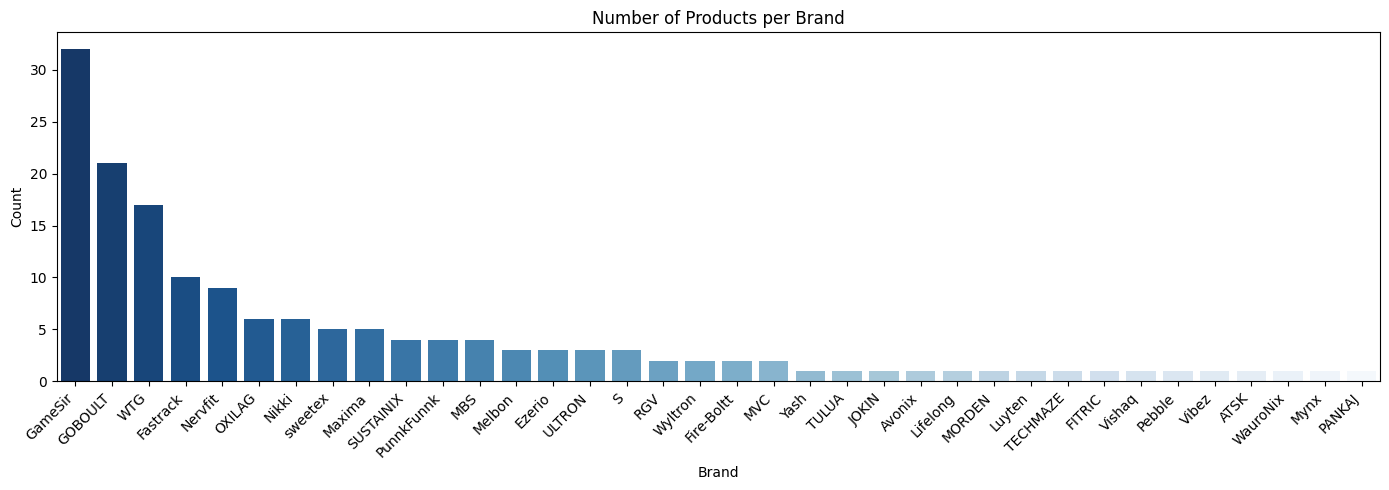


Total unique brands: 36
Brand
GameSir      32
GOBOULT      21
WTG          17
Fastrack     10
Nervfit       9
OXILAG        6
Nikki         6
sweetex       5
Maxima        5
SUSTAINIX     4
Name: count, dtype: int64


In [5]:
brand_counts = df['Brand'].value_counts()

plt.figure(figsize=(14, 5))
sns.barplot(x=brand_counts.index, y=brand_counts.values, palette='Blues_r')
plt.title('Number of Products per Brand')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotal unique brands: {df['Brand'].nunique()}")
print(brand_counts.head(10))

# **#5. Price Distribution — how are current prices spread?**

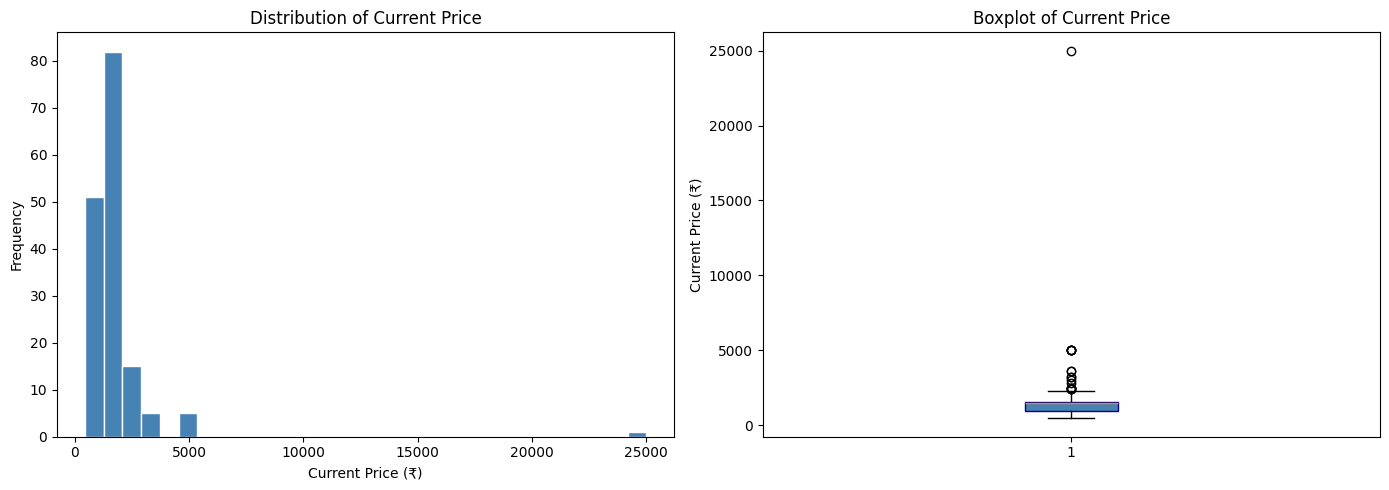


Price range: ₹449 — ₹24999
Mean price : ₹1664
Median price: ₹1447


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Current Price'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Current Price')
axes[0].set_xlabel('Current Price (₹)')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df['Current Price'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of Current Price')
axes[1].set_ylabel('Current Price (₹)')

plt.tight_layout()
plt.show()

print(f"\nPrice range: ₹{df['Current Price'].min():.0f} — ₹{df['Current Price'].max():.0f}")
print(f"Mean price : ₹{df['Current Price'].mean():.0f}")
print(f"Median price: ₹{df['Current Price'].median():.0f}")

# **#6. Average Price by Brand — which brand charges the most/least?**

/tmp/ipykernel_14083/1266450198.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, palette='coolwarm')


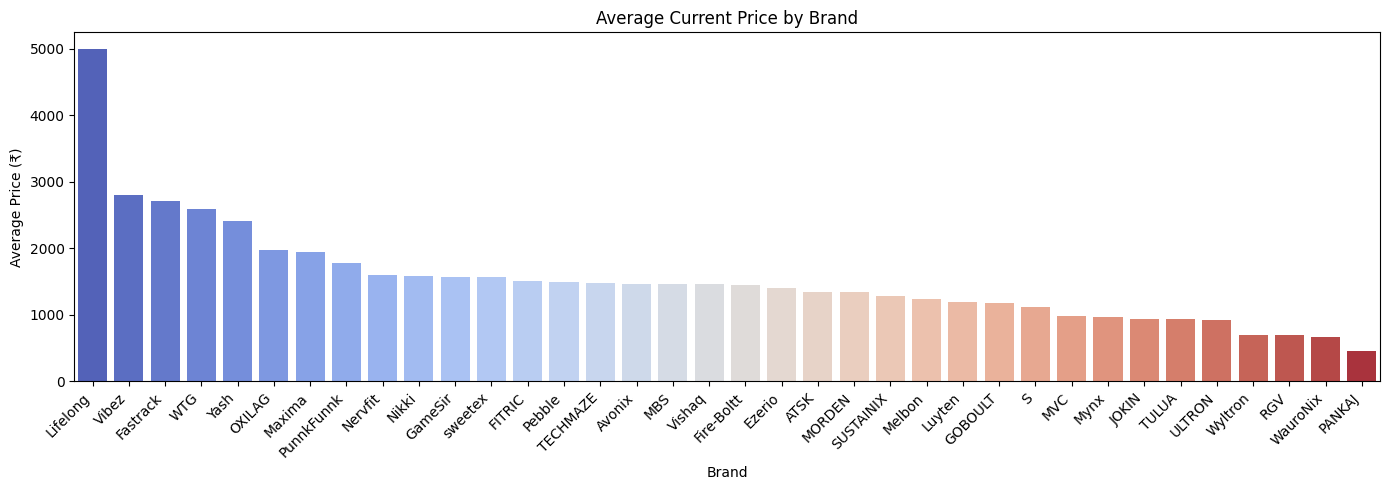

In [7]:
avg_price = df.groupby('Brand')['Current Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
sns.barplot(x=avg_price.index, y=avg_price.values, palette='coolwarm')
plt.title('Average Current Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **#7. Discount Analysis — what discounts are being offered?**

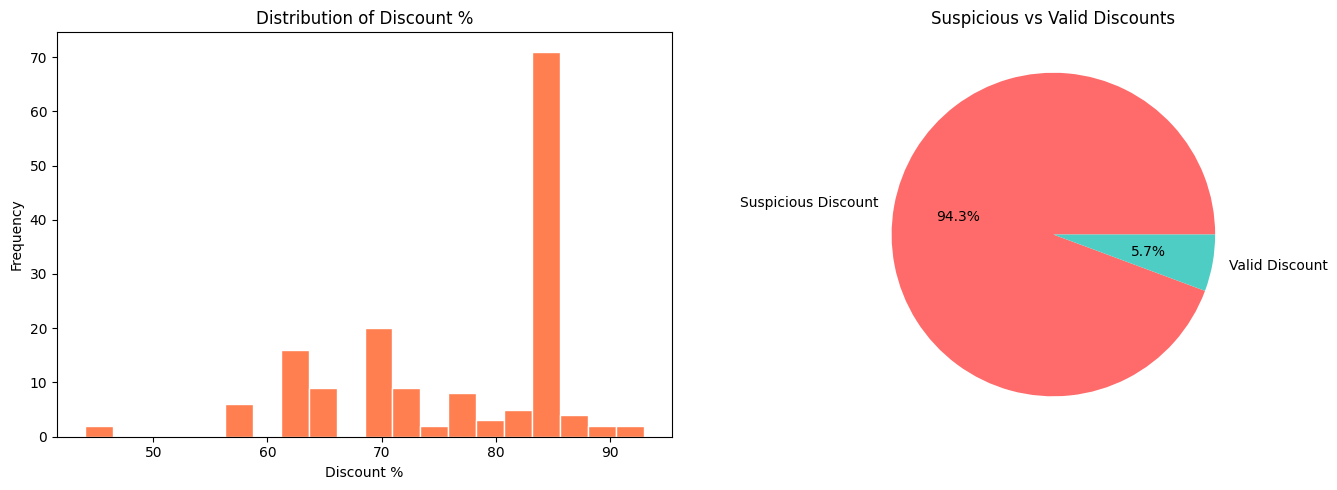


Suspicious discounts (>15% gap from calculated): 150 rows
Price anomalies (current > original): 80 rows


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Discount distribution
axes[0].hist(df['Discount %'].dropna(), bins=20, color='coral', edgecolor='white')
axes[0].set_title('Distribution of Discount %')
axes[0].set_xlabel('Discount %')
axes[0].set_ylabel('Frequency')

# Suspicious discounts
susp_counts = df['Discount Suspicious'].value_counts()
axes[1].pie(susp_counts.values,
            labels=['Suspicious Discount', 'Valid Discount'] if susp_counts.index[0] else ['Valid Discount', 'Suspicious Discount'],
            autopct='%1.1f%%',
            colors=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Suspicious vs Valid Discounts')

plt.tight_layout()
plt.show()

print(f"\nSuspicious discounts (>15% gap from calculated): {df['Discount Suspicious'].sum()} rows")
print(f"Price anomalies (current > original): {df['Price Anomaly'].sum()} rows")

# **#8. Display Type Distribution — AMOLED vs LCD/TFT?**

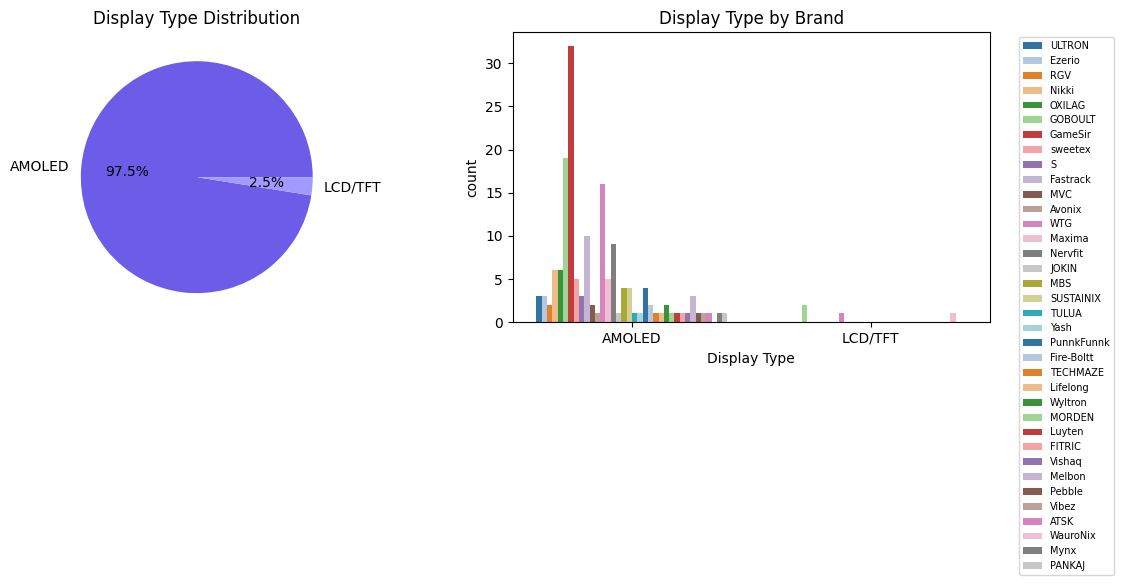

In [9]:
display_counts = df['Display Type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(display_counts.values, labels=display_counts.index, autopct='%1.1f%%',
            colors=['#6c5ce7', '#a29bfe', '#fd79a8'])
axes[0].set_title('Display Type Distribution')

sns.countplot(data=df, x='Display Type', hue='Brand', ax=axes[1], palette='tab20')
axes[1].set_title('Display Type by Brand')
axes[1].set_xlabel('Display Type')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

# **#9. Health Feature Count Distribution — how feature-rich are these watches?**

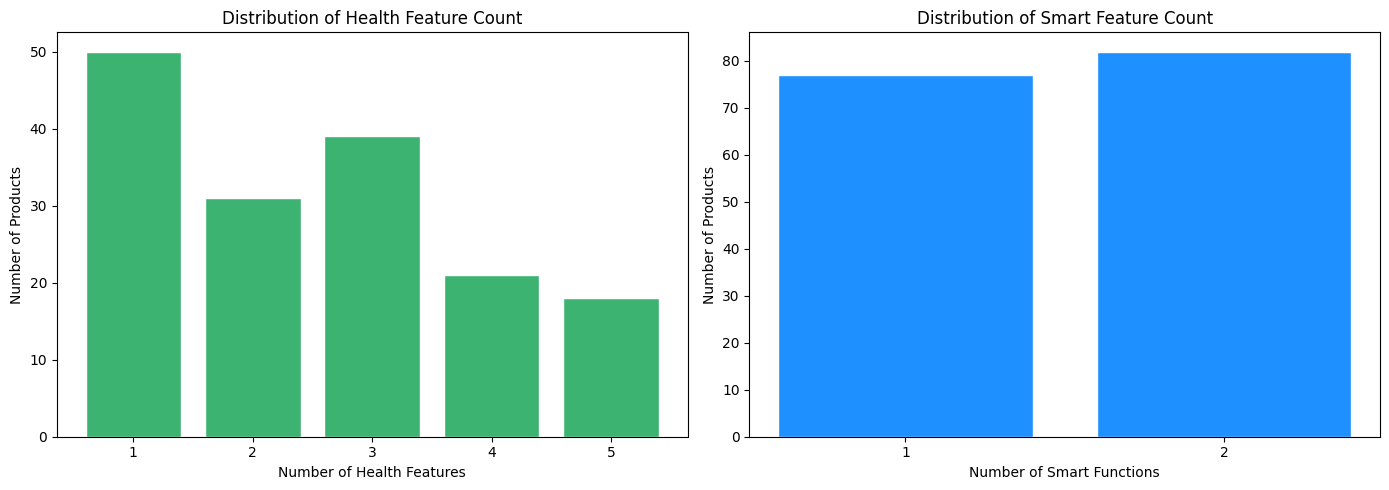

Average health features per watch: 2.53
Average smart features per watch : 1.52


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Health feature count
hf_counts = df['Health Feature Count'].value_counts().sort_index()
axes[0].bar(hf_counts.index, hf_counts.values, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Distribution of Health Feature Count')
axes[0].set_xlabel('Number of Health Features')
axes[0].set_ylabel('Number of Products')
axes[0].set_xticks(hf_counts.index)

# Smart feature count
sf_counts = df['Smart Feature Count'].value_counts().sort_index()
axes[1].bar(sf_counts.index, sf_counts.values, color='dodgerblue', edgecolor='white')
axes[1].set_title('Distribution of Smart Feature Count')
axes[1].set_xlabel('Number of Smart Functions')
axes[1].set_ylabel('Number of Products')
axes[1].set_xticks(sf_counts.index)

plt.tight_layout()
plt.show()

print(f"Average health features per watch: {df['Health Feature Count'].mean():.2f}")
print(f"Average smart features per watch : {df['Smart Feature Count'].mean():.2f}")

# **#10. Boolean Feature Breakdown — Heart Rate, Calorie Count, Step Count**

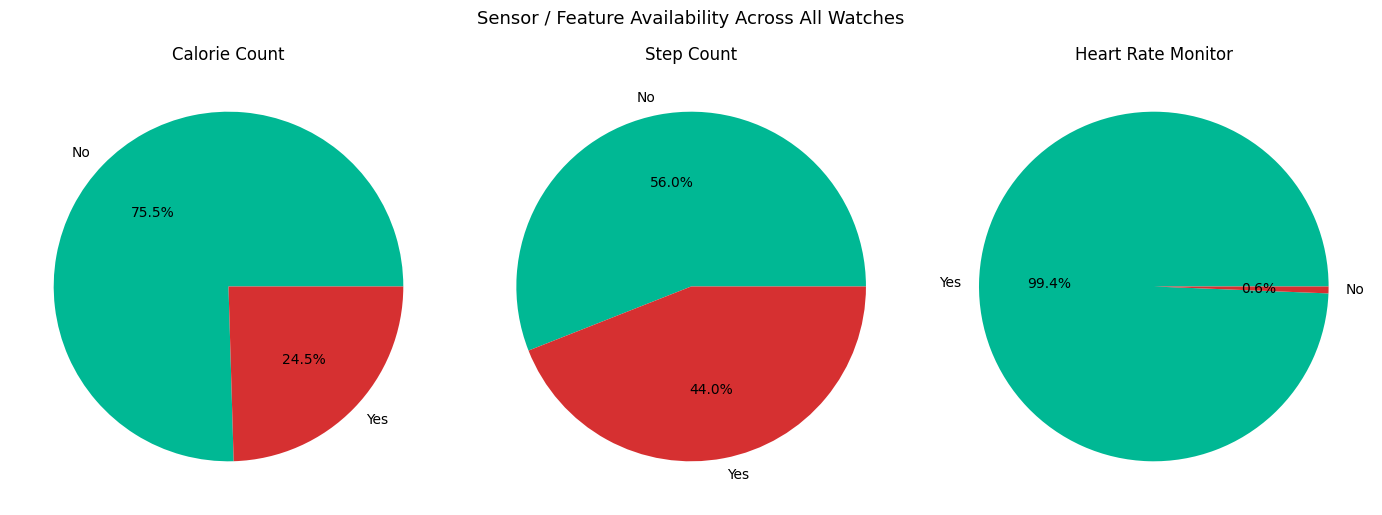

In [11]:
bool_cols = ['Calorie Count', 'Step Count', 'Heart Rate Monitor']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, bool_cols):
    counts = df[col].value_counts()
    ax.pie(counts.values,
           labels=['Yes' if idx else 'No' for idx in counts.index],
           autopct='%1.1f%%',
           colors=['#00b894', '#d63031'])
    ax.set_title(col)

plt.suptitle('Sensor / Feature Availability Across All Watches', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# **#11. Parent Company Analysis — who really owns these brands?**

/tmp/ipykernel_14083/3489295098.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=parent_counts.index, y=parent_counts.values, palette='magma')


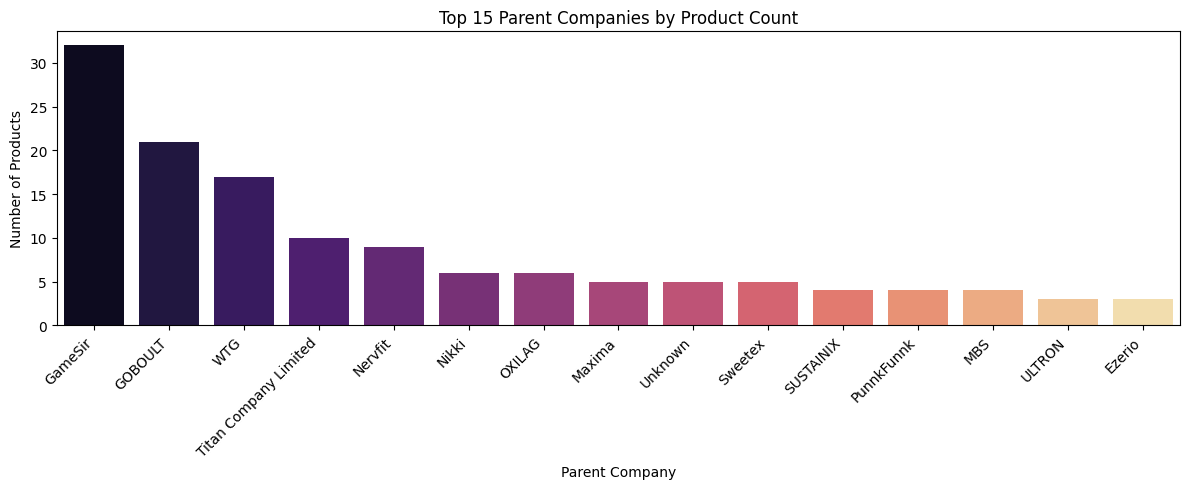


Unique parent companies: 35
Brands with 'Unknown' parent: 5 rows


In [12]:
parent_counts = df['parent_company'].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=parent_counts.index, y=parent_counts.values, palette='magma')
plt.title('Top 15 Parent Companies by Product Count')
plt.xlabel('Parent Company')
plt.ylabel('Number of Products')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nUnique parent companies: {df['parent_company'].nunique()}")
print(f"Brands with 'Unknown' parent: {(df['parent_company'] == 'Unknown').sum()} rows")

# **#12. Price vs Health Feature Count — do more features cost more?**

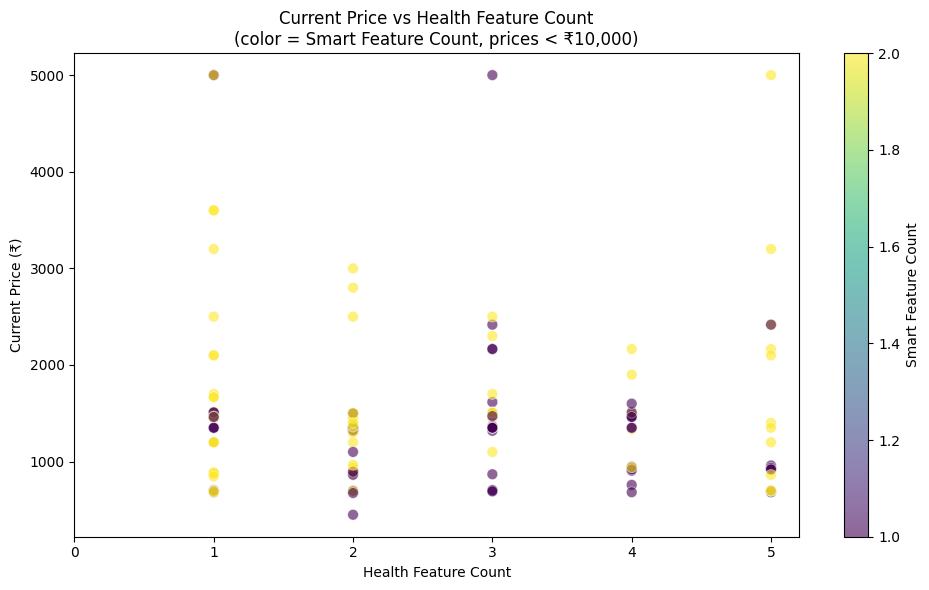

In [13]:
# Filter out extreme price anomalies for better visualization
df_clean = df[df['Current Price'] < 10000].copy()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_clean['Health Feature Count'],
    df_clean['Current Price'],
    c=df_clean['Smart Feature Count'],
    cmap='viridis',
    alpha=0.6,
    s=60,
    edgecolors='white',
    linewidths=0.5
)
plt.colorbar(scatter, label='Smart Feature Count')
plt.title('Current Price vs Health Feature Count\n(color = Smart Feature Count, prices < ₹10,000)')
plt.xlabel('Health Feature Count')
plt.ylabel('Current Price (₹)')
plt.xticks(range(0, df_clean['Health Feature Count'].max() + 1))
plt.tight_layout()
plt.show()

# **#13. Strap Type & Watch Shape Distribution**

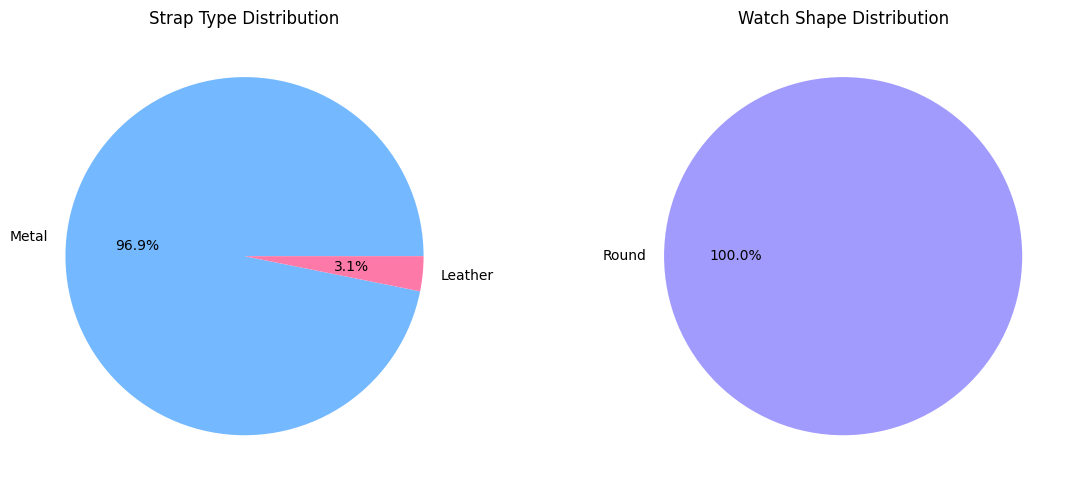

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

strap_counts = df['Strap Type'].value_counts()
axes[0].pie(strap_counts.values, labels=strap_counts.index,
            autopct='%1.1f%%', colors=['#74b9ff', '#fd79a8', '#55efc4'])
axes[0].set_title('Strap Type Distribution')

shape_counts = df['Watch Shape'].value_counts()
axes[1].pie(shape_counts.values, labels=shape_counts.index,
            autopct='%1.1f%%', colors=['#a29bfe', '#ffeaa7', '#ff7675'])
axes[1].set_title('Watch Shape Distribution')

plt.tight_layout()
plt.show()

# **#14. Correlation Heatmap — how do numeric features relate to each other?**

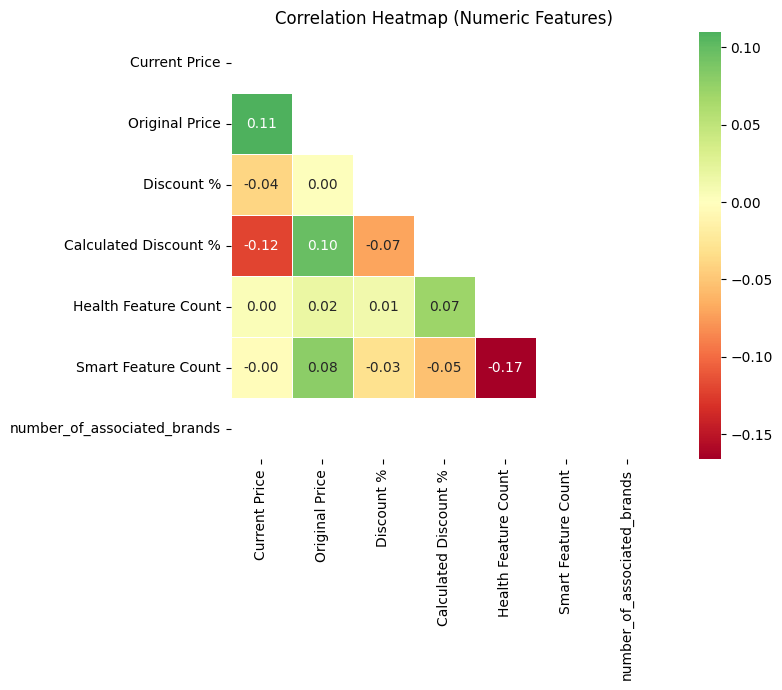

In [15]:
# Select numeric columns for correlation
numeric_cols = [
    'Current Price', 'Original Price', 'Discount %',
    'Calculated Discount %', 'Health Feature Count',
    'Smart Feature Count', 'number_of_associated_brands'
]

corr_df = df[numeric_cols].dropna()
corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

# **#15. Price Anomaly Deep-Dive — rows where Current Price > Original Price**

Price anomaly rows: 80


,Brand,Name,Current Price,Original Price,Discount %
144,WTG,"WTG i8 Pink 1.54"" HD Display Bluetooth Calling...",24999.0,4499.0,85.0
10,Fastrack,Fastrack Revoltt Pro-1.97'' Super AMOLED Displ...,4999.0,2499.0,46.0
59,Lifelong,Lifelong Luxury Smart Watch for Women |1.39 In...,4999.0,1999.0,84.0
120,GameSir,GameSir PF 9 Model : The Next Generation of wo...,4999.0,1461.0,70.0
139,GameSir,GameSir Gen 9 Model Fitness Health Music Smart...,4999.0,1461.0,62.0
147,OXILAG,OXILAG Gen9 with Dual Straps Calling notificat...,4999.0,1478.0,70.0
100,Vibez,Vibez by Lifelong Jewel Watch for Women with B...,2799.0,2659.0,70.0
113,Maxima,"Maxima Max Pro Bliss 1.19"" Super HD Display, B...",2499.0,2374.0,87.0
104,Nervfit,"Nervfit New Launch Orion S1 1.43"" AMOLED with ...",2499.0,1470.0,76.0
1,Ezerio,Ezerio Gen 9 Smart Watch for Women with Sleek ...,2416.0,1357.0,84.0


/tmp/ipykernel_14083/1248007995.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anomaly_by_brand.index, y=anomaly_by_brand.values, palette='Reds_r')


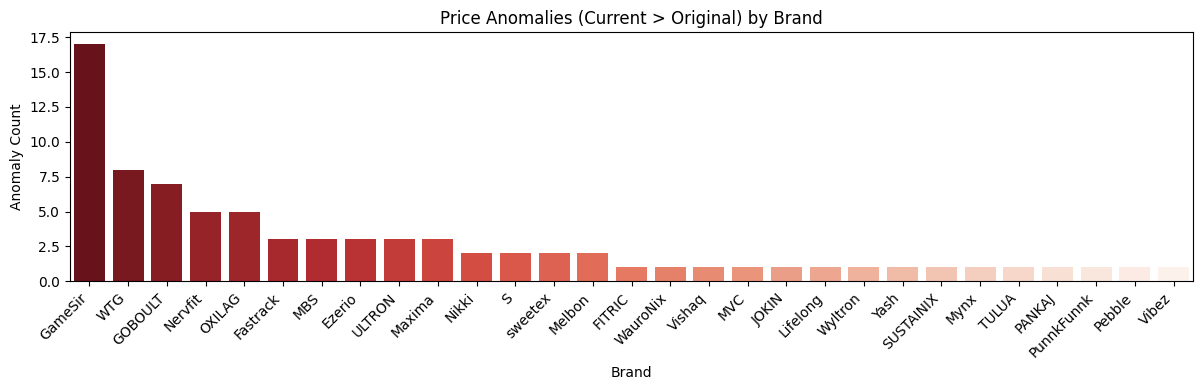

In [16]:
anomaly_df = df[df['Price Anomaly'] == True][['Brand', 'Name', 'Current Price', 'Original Price', 'Discount %']]
print(f"Price anomaly rows: {len(anomaly_df)}")
display(anomaly_df.sort_values('Current Price', ascending=False).head(20))

# Anomaly count per brand
anomaly_by_brand = df.groupby('Brand')['Price Anomaly'].sum().sort_values(ascending=False)
anomaly_by_brand = anomaly_by_brand[anomaly_by_brand > 0]

plt.figure(figsize=(12, 4))
sns.barplot(x=anomaly_by_brand.index, y=anomaly_by_brand.values, palette='Reds_r')
plt.title('Price Anomalies (Current > Original) by Brand')
plt.xlabel('Brand')
plt.ylabel('Anomaly Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **#16. Label Encoding — prepare categorical columns for ML**

In [17]:
le = LabelEncoder()

cat_cols_to_encode = ['Brand', 'Strap Type', 'Watch Shape', 'Display Type', 'parent_company']

for col in cat_cols_to_encode:
    df[col + '_encoded'] = le.fit_transform(df[col].fillna('Unknown').astype(str))
    print(f"✅ Encoded '{col}' → '{col}_encoded' ({df[col].nunique()} unique values)")

print("\n🔹 Preview of encoded columns:")
encoded_cols = [c + '_encoded' for c in cat_cols_to_encode]
display(df[cat_cols_to_encode + encoded_cols].head())

✅ Encoded 'Brand' → 'Brand_encoded' (36 unique values)
✅ Encoded 'Strap Type' → 'Strap Type_encoded' (2 unique values)
✅ Encoded 'Watch Shape' → 'Watch Shape_encoded' (1 unique values)
✅ Encoded 'Display Type' → 'Display Type_encoded' (2 unique values)
✅ Encoded 'parent_company' → 'parent_company_encoded' (35 unique values)

🔹 Preview of encoded columns:


,Brand,Strap Type,Watch Shape,Display Type,parent_company,Brand_encoded,Strap Type_encoded,Watch Shape_encoded,Display Type_encoded,parent_company_encoded
0,ULTRON,Metal,Round,AMOLED,ULTRON,28,1,0,0,27
1,Ezerio,Metal,Round,AMOLED,Ezerio,2,1,0,0,2
2,RGV,Metal,Round,AMOLED,RGV,23,1,0,0,21
3,Nikki,Metal,Round,AMOLED,Nikki,18,1,0,0,16
4,OXILAG,Metal,Round,AMOLED,OXILAG,19,1,0,0,17


# **#17. Save the final EDA-ready dataset to Google Drive**

In [18]:
output_path = "/content/drive/MyDrive/fitness_watches_eda_ready.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"\n✅ DataFrame saved to {output_path}")
print(f"Final shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n🔹 Final columns:")
print(df.columns.tolist())


✅ DataFrame saved to /content/drive/MyDrive/fitness_watches_eda_ready.csv
Final shape: 159 rows × 29 columns

🔹 Final columns:
['Name', 'Brand', 'Current Price', 'Original Price', 'Discount %', 'Strap Colour', 'Strap Type', 'Watch Shape', 'Display Size', 'Display Type', 'Calorie Count', 'Step Count', 'Heart Rate Monitor', 'Health Features', 'Smart Functions', 'brand', 'parent_company', 'number_of_associated_brands', 'Calculated Discount %', 'Discount Suspicious', 'Display Size (inches)', 'Health Feature Count', 'Smart Feature Count', 'Price Anomaly', 'Brand_encoded', 'Strap Type_encoded', 'Watch Shape_encoded', 'Display Type_encoded', 'parent_company_encoded']


In [19]:
# Remove price-anomaly rows (current > original) — scraping errors
df_ml = df[df['Price Anomaly'] == False].copy()

# Remove extreme price outliers (beyond 3 standard deviations)
price_mean = df_ml['Current Price'].mean()
price_std  = df_ml['Current Price'].std()
df_ml = df_ml[
    (df_ml['Current Price'] < price_mean + 3 * price_std) &
    (df_ml['Current Price'] > 100)
]

# Drop zero-variance column
df_ml.drop(columns=['number_of_associated_brands'], inplace=True)

print(f"Original rows : {len(df)}")
print(f"Rows after cleaning: {len(df_ml)}")
print(f"Rows removed : {len(df) - len(df_ml)}")

Original rows : 159
Rows after cleaning: 77
Rows removed : 82


In [20]:
ml_output_path = "/content/drive/MyDrive/fitness_watches_ml_ready.csv"
df_ml.to_csv(ml_output_path, index=False, encoding='utf-8-sig')

print(f"✅ ML-ready dataset saved to {ml_output_path}")
print(f"Final shape: {df_ml.shape[0]} rows × {df_ml.shape[1]} columns")

✅ ML-ready dataset saved to /content/drive/MyDrive/fitness_watches_ml_ready.csv
Final shape: 77 rows × 28 columns
